# Spam Text Message Classification

## Machine Learning Assignment

**Assignment Type:** Text Analysis / NLP  
**Learning Type:** Classification  
**Algorithm:** Logistic Regression  

### Student Details
Name: Benji E  
ID: 6477

## Problem Description

The goal of this project is to build a machine learning model that classifies SMS text messages as either spam or ham (legitimate messages).

The dataset used in this project is the Spam Text Message Classification dataset from Kaggle.

This is a supervised binary classification problem.

## AI / Chatbot Assistance

AI chatbot assistance was used during the development of this assignment.

Examples of prompts used:

- "How should I start the machine learning assignment using the Spam Text Message Classification dataset?"
  - Purpose: Planning the structure of the assignment.

- "How should I structure the Jupyter Notebook for spam classification?"
  - Purpose: Organizing the notebook according to the assignment requirements.

- "How can Logistic Regression be implemented from scratch using NumPy?"
  - Purpose: Understanding and reviewing the implementation of the learning algorithm.

- "How should Grid Search and 5-Fold Cross Validation be performed without data leakage?"
  - Purpose: Understanding the correct model-selection workflow.

- "How can Logistic Regression weights be used for model explainability?"
  - Purpose: Understanding and presenting the features that influence spam and ham predictions.

AI assistance was used as a learning and development aid. The implementation, execution, analysis and understanding of the results were reviewed as part of this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SPAM text message 20170820 - Data.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Dataset Exploration

In this section, we examine the structure of the dataset, check for missing or duplicate values, and inspect the distribution of the target classes.

In [2]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["Category"].value_counts())

Dataset shape: (5572, 2)

Columns:
['Category', 'Message']

Missing values:
Category    0
Message     0
dtype: int64

Duplicate rows:
415

Class distribution:
Category
ham     4825
spam     747
Name: count, dtype: int64


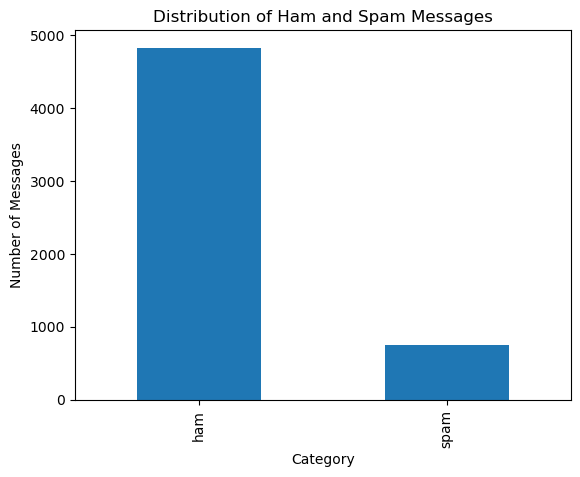

In [3]:
df["Category"].value_counts().plot(kind="bar")

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Category")
plt.ylabel("Number of Messages")
plt.show()

## Data Cleaning

The dataset contains no missing values, but duplicate messages were detected.

Duplicate rows are removed before creating the training and test sets in order to prevent the same message from appearing in both sets and causing data leakage.

In [4]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

print("\nClass distribution after cleaning:")
print(df["Category"].value_counts())

Dataset shape after removing duplicates: (5157, 2)

Class distribution after cleaning:
Category
ham     4516
spam     641
Name: count, dtype: int64


## Train and Test Sets

The cleaned dataset is divided once into a training set and a test set.

A stratified split is used to preserve the original proportion of spam and ham messages in both datasets.

The test set will remain untouched during model training and hyperparameter selection.

In [6]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Category"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (4125, 2)
Test set shape: (1032, 2)


In [7]:
print("First 5 rows of the training set:")
display(train_df.head())

print("\nFirst 5 rows of the test set:")
display(test_df.head())

First 5 rows of the training set:


,Category,Message
0,ham,Saw Guys and Dolls last night with Patrick Swa...
1,ham,Nothing but we jus tot u would ask cos u ba gu...
2,ham,Oh really?? Did you make it on air? What's you...
3,spam,TheMob>Hit the link to get a premium Pink Pant...
4,spam,"New Mobiles from 2004, MUST GO! Txt: NOKIA to ..."



First 5 rows of the test set:


,Category,Message
0,ham,Can you plz tell me the ans. BSLVYL sent via f...
1,ham,You intrepid duo you! Have a great time and se...
2,ham,R u in this continent?
3,ham,"Cool, want me to go to kappa or should I meet ..."
4,ham,I'm meeting Darren...


In [8]:
print("Training set distribution:")
print(train_df["Category"].value_counts(normalize=True))

print("\nTest set distribution:")
print(test_df["Category"].value_counts(normalize=True))

Training set distribution:
Category
ham     0.875636
spam    0.124364
Name: proportion, dtype: float64

Test set distribution:
Category
ham     0.875969
spam    0.124031
Name: proportion, dtype: float64


## Text Preprocessing and Feature Engineering

Text messages cannot be used directly by a machine learning algorithm.

The messages are first cleaned and normalized, and then TF-IDF is used to convert the text into numerical feature vectors.

The TF-IDF vectorizer is fitted only on the training set in order to prevent information leakage from the test set.

In [9]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


train_df["Clean_Message"] = train_df["Message"].apply(clean_text)
test_df["Clean_Message"] = test_df["Message"].apply(clean_text)

In [10]:
print("Training examples:")
display(train_df[["Message", "Clean_Message", "Category"]].head(3))

print("\nTest examples:")
display(test_df[["Message", "Clean_Message", "Category"]].head(3))

Training examples:


,Message,Clean_Message,Category
0,Saw Guys and Dolls last night with Patrick Swa...,saw guys and dolls last night with patrick swa...,ham
1,Nothing but we jus tot u would ask cos u ba gu...,nothing but we jus tot u would ask cos u ba gu...,ham
2,Oh really?? Did you make it on air? What's you...,oh really?? did you make it on air? what's you...,ham



Test examples:


,Message,Clean_Message,Category
0,Can you plz tell me the ans. BSLVYL sent via f...,can you plz tell me the ans. bslvyl sent via f...,ham
1,You intrepid duo you! Have a great time and se...,you intrepid duo you! have a great time and se...,ham
2,R u in this continent?,r u in this continent?,ham


In [11]:
train_df["Label"] = train_df["Category"].map({
    "ham": 0,
    "spam": 1
})

test_df["Label"] = test_df["Category"].map({
    "ham": 0,
    "spam": 1
})

y_train = train_df["Label"].values
y_test = test_df["Label"].values

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 1)
)

X_train = tfidf.fit_transform(train_df["Clean_Message"])
X_test = tfidf.transform(test_df["Clean_Message"])

print("Training feature matrix:", X_train.shape)
print("Test feature matrix:", X_test.shape)

Training feature matrix: (4125, 3000)
Test feature matrix: (1032, 3000)


In [14]:
feature_names = tfidf.get_feature_names_out()

def show_tfidf_examples(X, dataframe, number_of_examples=3):
    for i in range(number_of_examples):
        values = X[i].toarray()[0]
        top_indices = values.argsort()[-5:][::-1]

        print(f"\nMessage {i + 1}:")
        print(dataframe.loc[i, "Clean_Message"])

        print("Top TF-IDF features:")
        for index in top_indices:
            if values[index] > 0:
                print(f"  {feature_names[index]}: {values[index]:.4f}")

print("TRAINING EXAMPLES")
show_tfidf_examples(X_train, train_df)

print("\nTEST EXAMPLES")
show_tfidf_examples(X_test, test_df)

TRAINING EXAMPLES

Message 1:
saw guys and dolls last night with patrick swayze it was great
Top TF-IDF features:
  saw: 0.4477
  guys: 0.4180
  last: 0.3670
  great: 0.3468
  night: 0.3434

Message 2:
nothing but we jus tot u would ask cos u ba gua... but we went mt faber yest... yest jus went out already mah so today not going out... jus call lor...
Top TF-IDF features:
  jus: 0.4966
  yest: 0.4237
  went: 0.3138
  ba: 0.2259
  out: 0.2208

Message 3:
oh really?? did you make it on air? what's your talent?
Top TF-IDF features:
  talent: 0.4955
  air: 0.4537
  really: 0.3093
  make: 0.2985
  oh: 0.2927

TEST EXAMPLES

Message 1:
can you plz tell me the ans. bslvyl sent via fullonsms.com
Top TF-IDF features:
  fullonsms: 0.4127
  ans: 0.3779
  bslvyl: 0.3702
  via: 0.3523
  plz: 0.3431

Message 2:
you intrepid duo you! have a great time and see you both soon.
Top TF-IDF features:
  you: 0.4697
  both: 0.4611
  soon: 0.3949
  great: 0.3478
  see: 0.3211

Message 3:
r u in this continent

## Evaluation Metric - F1 Score

The primary evaluation metric used in this project is the **F1 Score for the Spam class**.

Spam is considered the positive class.

The F1 Score combines Precision and Recall:

**Precision** measures how many messages predicted as spam are actually spam.

**Recall** measures how many actual spam messages were successfully detected.

The F1 Score is especially suitable for this dataset because the classes are imbalanced, with significantly more ham messages than spam messages.

Therefore, accuracy alone could be misleading, while F1 provides a better measure of the model's ability to detect spam.

## Logistic Regression Implementation

Logistic Regression is implemented from scratch using NumPy.

The model calculates a weighted linear combination of the TF-IDF features and applies the sigmoid function to produce a probability between 0 and 1.

The model is trained using gradient descent.

The implementation supports several hyperparameters:

- Learning rate
- Number of training epochs
- Classification threshold
- L2 regularization strength

In [15]:
class LogisticRegressionScratch:
    
    def __init__(self, learning_rate=0.1, epochs=500, threshold=0.5, l2=0.0):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.threshold = threshold
        self.l2 = l2
        
        self.weights = None
        self.bias = 0.0
        self.loss_history = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):

            # Linear model
            linear_output = X.dot(self.weights) + self.bias

            # Convert output to probability
            probabilities = self.sigmoid(linear_output)

            # Difference between prediction and real label
            errors = probabilities - y

            # Gradients
            dw = np.asarray(X.T.dot(errors)).ravel() / n_samples
            db = np.mean(errors)

            # L2 regularization
            dw += (self.l2 / n_samples) * self.weights

            # Gradient descent update
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Binary cross-entropy loss
            epsilon = 1e-15

            loss = -np.mean(
                y * np.log(probabilities + epsilon) +
                (1 - y) * np.log(1 - probabilities + epsilon)
            )

            loss += (self.l2 / (2 * n_samples)) * np.sum(self.weights ** 2)

            self.loss_history.append(loss)

        return self

    def predict_proba(self, X):
        linear_output = X.dot(self.weights) + self.bias
        return self.sigmoid(linear_output)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return (probabilities >= self.threshold).astype(int)

In [16]:
model = LogisticRegressionScratch(
    learning_rate=0.1,
    epochs=500,
    threshold=0.5,
    l2=0.0
)

model.fit(X_train, y_train)

print("Training completed.")
print("Final training loss:", model.loss_history[-1])

Training completed.
Final training loss: 0.3532863519161859


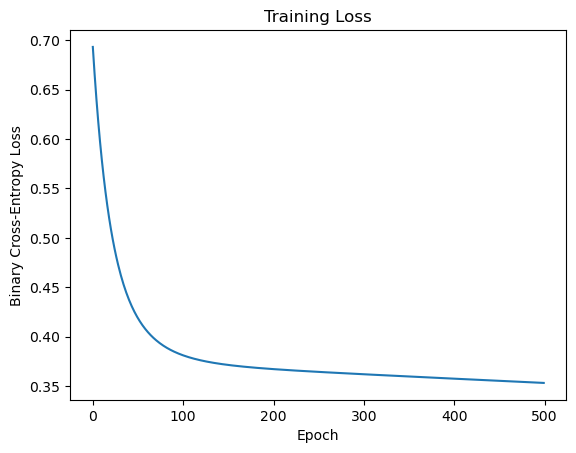

In [17]:
plt.plot(model.loss_history)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

## Hyperparameter Tuning with 5-Fold Cross Validation

To select the best model configuration, a manual Grid Search is performed using 5-Fold Stratified Cross Validation.

For each fold:

1. TF-IDF is fitted only on the training portion of the fold.
2. The validation portion is transformed using the same TF-IDF vocabulary.
3. A new Logistic Regression model is trained from scratch.
4. The F1 Score of the spam class is calculated.

The mean F1 Score across the five folds is used to compare the different configurations.

In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from itertools import product

X_text = train_df["Clean_Message"].reset_index(drop=True)
y = train_df["Label"].values

parameter_grid = {
    "max_features": [2000, 3000],
    "ngram_range": [(1, 1), (1, 2)],
    "learning_rate": [0.1, 0.3],
    "l2": [0.0, 0.1],
    "threshold": [0.13, 0.14]
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

combinations = list(product(
    parameter_grid["max_features"],
    parameter_grid["ngram_range"],
    parameter_grid["learning_rate"],
    parameter_grid["l2"],
    parameter_grid["threshold"]
))

print("Number of parameter combinations:", len(combinations))

Number of parameter combinations: 32


In [27]:
for combination_number, (
    max_features,
    ngram_range,
    learning_rate,
    l2,
    threshold
) in enumerate(combinations, 1):

    fold_scores = []

    print(
        f"Combination {combination_number}/{len(combinations)} - "
        f"max_features={max_features}, "
        f"ngram_range={ngram_range}, "
        f"learning_rate={learning_rate}, "
        f"l2={l2}, "
        f"threshold={threshold}"
    )

    for train_index, val_index in skf.split(X_text, y):

        X_fold_train_text = X_text.iloc[train_index]
        X_fold_val_text = X_text.iloc[val_index]

        y_fold_train = y[train_index]
        y_fold_val = y[val_index]

        # Fit TF-IDF only on the training portion of this fold
        fold_tfidf = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range
        )

        X_fold_train = fold_tfidf.fit_transform(X_fold_train_text)
        X_fold_val = fold_tfidf.transform(X_fold_val_text)

        # Train Logistic Regression from scratch
        fold_model = LogisticRegressionScratch(
            learning_rate=learning_rate,
            epochs=1000,
            threshold=threshold,
            l2=l2
        )

        fold_model.fit(X_fold_train, y_fold_train)

        # Predict validation set
        y_fold_pred = fold_model.predict(X_fold_val)

        # F1 score for Spam class
        fold_f1 = f1_score(
            y_fold_val,
            y_fold_pred,
            pos_label=1
        )

        fold_scores.append(fold_f1)

    mean_f1 = np.mean(fold_scores)

    results.append({
        "max_features": max_features,
        "ngram_range": str(ngram_range),
        "learning_rate": learning_rate,
        "l2": l2,
        "threshold": threshold,
        "mean_f1": mean_f1
    })

Combination 1/32 - max_features=2000, ngram_range=(1, 1), learning_rate=0.1, l2=0.0, threshold=0.13
Combination 2/32 - max_features=2000, ngram_range=(1, 1), learning_rate=0.1, l2=0.0, threshold=0.14
Combination 3/32 - max_features=2000, ngram_range=(1, 1), learning_rate=0.1, l2=0.1, threshold=0.13
Combination 4/32 - max_features=2000, ngram_range=(1, 1), learning_rate=0.1, l2=0.1, threshold=0.14
Combination 5/32 - max_features=2000, ngram_range=(1, 1), learning_rate=0.3, l2=0.0, threshold=0.13
Combination 6/32 - max_features=2000, ngram_range=(1, 1), learning_rate=0.3, l2=0.0, threshold=0.14
Combination 7/32 - max_features=2000, ngram_range=(1, 1), learning_rate=0.3, l2=0.1, threshold=0.13
Combination 8/32 - max_features=2000, ngram_range=(1, 1), learning_rate=0.3, l2=0.1, threshold=0.14
Combination 9/32 - max_features=2000, ngram_range=(1, 2), learning_rate=0.1, l2=0.0, threshold=0.13
Combination 10/32 - max_features=2000, ngram_range=(1, 2), learning_rate=0.1, l2=0.0, threshold=0.14

In [28]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="mean_f1",
    ascending=False
).reset_index(drop=True)

display(results_df)

,max_features,ngram_range,learning_rate,l2,threshold,mean_f1
0,3000,"(1, 2)",0.1,0.0,0.14,0.898905
1,3000,"(1, 2)",0.1,0.1,0.14,0.898905
2,3000,"(1, 1)",0.1,0.1,0.14,0.888520
3,3000,"(1, 1)",0.1,0.0,0.14,0.888520
4,2000,"(1, 2)",0.1,0.1,0.14,0.887198
5,2000,"(1, 2)",0.1,0.0,0.14,0.887198
6,2000,"(1, 1)",0.1,0.0,0.14,0.884431
7,2000,"(1, 1)",0.1,0.1,0.14,0.884431
8,3000,"(1, 2)",0.3,0.1,0.14,0.814042
9,3000,"(1, 2)",0.3,0.0,0.14,0.814042


In [29]:
best_result = results_df.iloc[0]

print("Best configuration:")
print(best_result)

Best configuration:
max_features         3000
ngram_range        (1, 2)
learning_rate         0.1
l2                    0.0
threshold            0.14
mean_f1          0.898905
Name: 0, dtype: object


## Final Model Training

The best configuration found during 5-Fold Cross Validation is now used to train the final model on the entire training set.

Best configuration:

- Maximum TF-IDF features: 3000
- N-gram range: (1, 2)
- Learning rate: 0.1
- L2 regularization: 0.0
- Classification threshold: 0.14

The test set is not used during training.

In [30]:
final_tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

X_train_final = final_tfidf.fit_transform(
    train_df["Clean_Message"]
)

X_test_final = final_tfidf.transform(
    test_df["Clean_Message"]
)

print("Final training feature matrix:", X_train_final.shape)
print("Final test feature matrix:", X_test_final.shape)

Final training feature matrix: (4125, 3000)
Final test feature matrix: (1032, 3000)


In [31]:
final_model = LogisticRegressionScratch(
    learning_rate=0.1,
    epochs=1000,
    threshold=0.14,
    l2=0.0
)

final_model.fit(
    X_train_final,
    y_train
)

print("Final model training completed.")
print("Final training loss:", final_model.loss_history[-1])

Final model training completed.
Final training loss: 0.3365109277951287


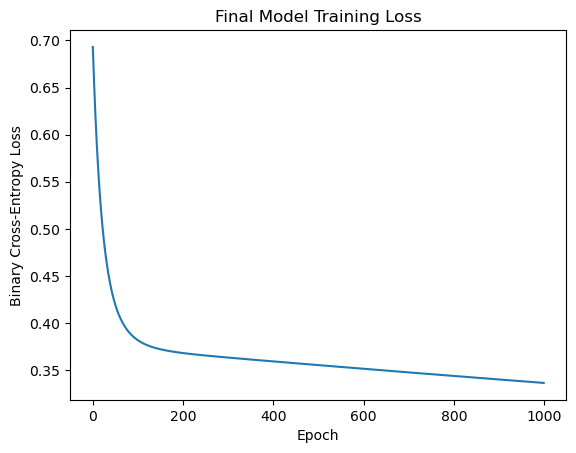

In [32]:
plt.plot(final_model.loss_history)

plt.title("Final Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

## Final Test Set Evaluation

The final trained model is now evaluated on the previously untouched test set.

The primary evaluation metric is the F1 Score for the Spam class.

In [33]:
test_probabilities = final_model.predict_proba(X_test_final)
y_test_pred = final_model.predict(X_test_final)

final_f1 = f1_score(
    y_test,
    y_test_pred,
    pos_label=1
)

print("Final Test F1 Score:", final_f1)

Final Test F1 Score: 0.8458498023715415


In [34]:
prediction_results = test_df[
    ["Message", "Category"]
].copy()

prediction_results["Predicted"] = np.where(
    y_test_pred == 1,
    "spam",
    "ham"
)

prediction_results["Spam Probability"] = test_probabilities

display(prediction_results.head(5))

,Message,Category,Predicted,Spam Probability
0,Can you plz tell me the ans. BSLVYL sent via f...,ham,ham,0.118417
1,You intrepid duo you! Have a great time and se...,ham,ham,0.117817
2,R u in this continent?,ham,ham,0.121666
3,"Cool, want me to go to kappa or should I meet ...",ham,ham,0.126779
4,I'm meeting Darren...,ham,ham,0.123989


In [35]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

precision = precision_score(y_test, y_test_pred, pos_label=1)
recall = recall_score(y_test, y_test_pred, pos_label=1)

print(f"F1 Score:  {final_f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

F1 Score:  0.8458
Precision: 0.8560
Recall:    0.8359

Confusion Matrix:
[[886  18]
 [ 21 107]]


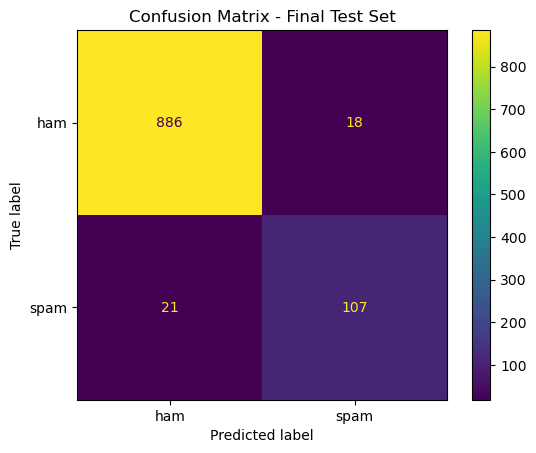

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["ham", "spam"]
)

plt.title("Confusion Matrix - Final Test Set")
plt.show()

## Evaluation Summary

The final Logistic Regression model achieved an F1 Score of approximately **0.846** on the previously unseen test set.

The model achieved:

- Precision: **0.856**
- Recall: **0.836**
- F1 Score: **0.846**

The confusion matrix shows that the model correctly classified 107 spam messages and 886 ham messages.

There were 18 false positive predictions, where legitimate messages were classified as spam, and 21 false negatives, where spam messages were classified as ham.

The final test result is lower than the best cross-validation score of approximately 0.899, which is expected because the test set contains previously unseen data.

## Conclusion

In this project, an SMS spam classification system was developed using TF-IDF feature engineering and a Logistic Regression algorithm implemented from scratch.

The dataset was cleaned by removing duplicate messages and was divided into training and test sets using stratified sampling.

A manual Grid Search with 5-Fold Cross Validation was used to evaluate different TF-IDF configurations and Logistic Regression hyperparameters.

The best configuration used:

- 3000 TF-IDF features
- Unigrams and bigrams
- Learning rate of 0.1
- Classification threshold of 0.14
- No L2 regularization

The final model achieved an F1 Score of approximately **0.846** on the test set.

The results demonstrate that TF-IDF combined with Logistic Regression can effectively distinguish spam messages from legitimate SMS messages.

## Model Explainability

Logistic Regression assigns a weight to every TF-IDF feature.

Positive weights increase the probability that a message will be classified as spam, while negative weights indicate features that are more strongly associated with ham messages.

The following analysis displays the features with the strongest positive and negative weights in the final model.

In [37]:
final_feature_names = final_tfidf.get_feature_names_out()

weights = final_model.weights

top_spam_indices = np.argsort(weights)[-15:][::-1]
top_ham_indices = np.argsort(weights)[:15]

spam_features = pd.DataFrame({
    "Feature": final_feature_names[top_spam_indices],
    "Weight": weights[top_spam_indices]
})

ham_features = pd.DataFrame({
    "Feature": final_feature_names[top_ham_indices],
    "Weight": weights[top_ham_indices]
})

print("Top features associated with SPAM:")
display(spam_features)

print("Top features associated with HAM:")
display(ham_features)

Top features associated with SPAM:


,Feature,Weight
0,call,0.498397
1,free,0.406046
2,txt,0.334524
3,to,0.301625
4,your,0.278732
5,mobile,0.274607
6,url,0.264727
7,stop,0.249919
8,text,0.243142
9,claim,0.239228


Top features associated with HAM:


,Feature,Weight
0,my,-0.237028
1,me,-0.227287
2,in,-0.196126
3,it,-0.195327
4,you,-0.181996
5,that,-0.177151
6,ok,-0.169795
7,but,-0.156892
8,so,-0.142347
9,how,-0.140072


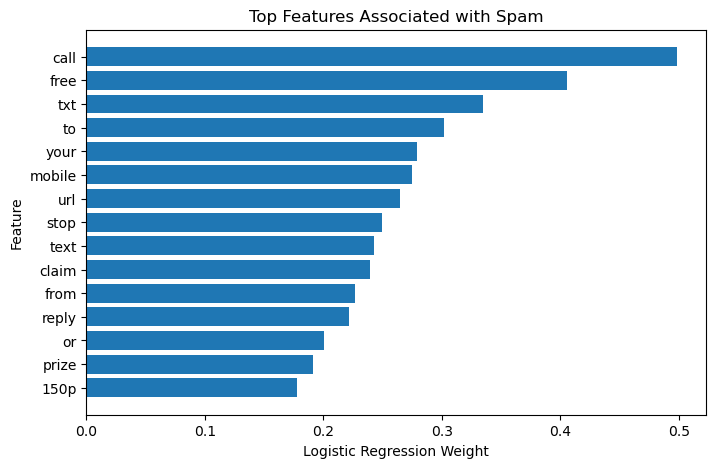

In [38]:
plt.figure(figsize=(8, 5))

plt.barh(
    spam_features["Feature"][::-1],
    spam_features["Weight"][::-1]
)

plt.title("Top Features Associated with Spam")
plt.xlabel("Logistic Regression Weight")
plt.ylabel("Feature")
plt.show()

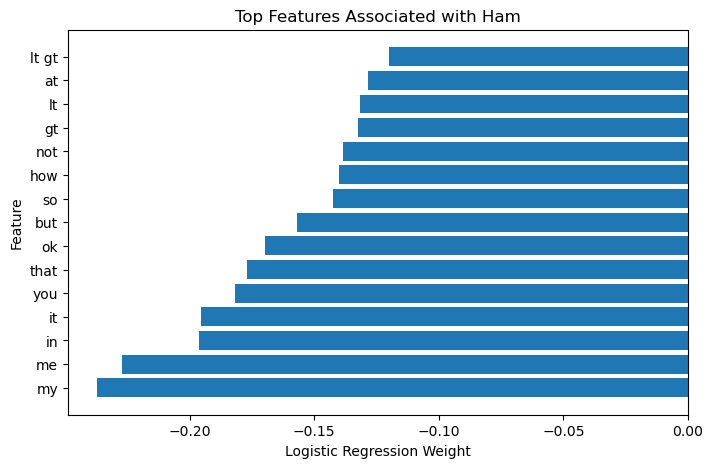

In [39]:
plt.figure(figsize=(8, 5))

plt.barh(
    ham_features["Feature"],
    ham_features["Weight"]
)

plt.title("Top Features Associated with Ham")
plt.xlabel("Logistic Regression Weight")
plt.ylabel("Feature")
plt.show()

### Explainability Analysis

The Logistic Regression weights provide insight into how the model makes its predictions.

Features with positive weights, such as **call, free, txt, mobile, claim, prize, and 150p**, push the prediction toward the spam class.

Features with negative weights, such as **my, me, ok, how, and not**, push the prediction toward the ham class.

This shows that the model learned meaningful and interpretable patterns from the SMS messages.